# Voting Classifier using Sklearn

A Voting Classifier is a machine learning model that trains on an ensemble of numerous models and predicts an output (class) based on their highest probability of chosen class as the output.

It simply aggregates the findings of each classifier passed into Voting Classifier and predicts the output class based on the highest majority of voting. 

## Voting Classifier supports two types of votings.

## Hard Voting:
In hard voting, the predicted output class is a class with the highest majority of votes i.e the class which had the highest probability of being predicted by each of the classifiers. Suppose three classifiers predicted the output class(A, A, B), so here the majority predicted A as output. Hence A will be the final prediction.
## Soft Voting:
In soft voting, the output class is the prediction based on the average of probability given to that class. Suppose given some input to three models, the prediction probability for class A = (0.30, 0.47, 0.53) and B = (0.20, 0.32, 0.40). So the average for class A is 0.4333 and B is 0.3067, the winner is clearly class A because it had the highest probability averaged by each classifier.

# Python code to implement Voting Classifier
This code loads the Iris dataset, splits it into training and test sets, and then trains a Voting Classifier using Logistic Regression, Random Forest, and SVM. It uses soft voting, meaning it considers predicted probabilities for final predictions.


In [14]:
# importing libraries 
from sklearn.ensemble import VotingClassifier 
from sklearn.linear_model import LogisticRegression 
from sklearn.svm import SVC 
from sklearn.ensemble import RandomForestClassifier 
from sklearn.datasets import load_iris 
from sklearn.metrics import accuracy_score 
from sklearn.model_selection import train_test_split 
import matplotlib.pyplot as plt

In [5]:
# Load dataset
data = load_iris()
X, y = data.data, data.target

In [6]:
# train_test_split 
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size = 0.20, random_state = 42) 
  

In [7]:
# Define base classifiers
log_clf = LogisticRegression(max_iter=200, random_state=42)
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)
svm_clf = SVC(probability=True, random_state=42)


In [8]:
# Create a Voting Classifier (Hard Voting)
hard_voting_clf = VotingClassifier(
    estimators=[('lr', log_clf), ('rf', rf_clf), ('svm', svm_clf)],
    voting='hard'  # Hard voting: Majority rule
)

In [9]:
# Train the hard voting classifier
hard_voting_clf.fit(X_train, y_train)


VotingClassifier(estimators=[('lr',
                              LogisticRegression(max_iter=200,
                                                 random_state=42)),
                             ('rf', RandomForestClassifier(random_state=42)),
                             ('svm', SVC(probability=True, random_state=42))])

In [10]:
# Predict and evaluate using hard voting
y_pred_hard = hard_voting_clf.predict(X_test)
hard_accuracy = accuracy_score(y_test, y_pred_hard)
print(f'Hard Voting Classifier Accuracy: {hard_accuracy:.2f}')


Hard Voting Classifier Accuracy: 1.00


In [11]:
# Create a Voting Classifier (Soft Voting)
soft_voting_clf = VotingClassifier(
    estimators=[('lr', log_clf), ('rf', rf_clf), ('svm', svm_clf)],
    voting='soft'  # Soft voting: Weighted probability-based decision
)


In [12]:
# Train the soft voting classifier
soft_voting_clf.fit(X_train, y_train)


VotingClassifier(estimators=[('lr',
                              LogisticRegression(max_iter=200,
                                                 random_state=42)),
                             ('rf', RandomForestClassifier(random_state=42)),
                             ('svm', SVC(probability=True, random_state=42))],
                 voting='soft')

In [13]:
# Predict and evaluate using soft voting
y_pred_soft = soft_voting_clf.predict(X_test)
soft_accuracy = accuracy_score(y_test, y_pred_soft)
print(f'Soft Voting Classifier Accuracy: {soft_accuracy:.2f}')


Soft Voting Classifier Accuracy: 1.00


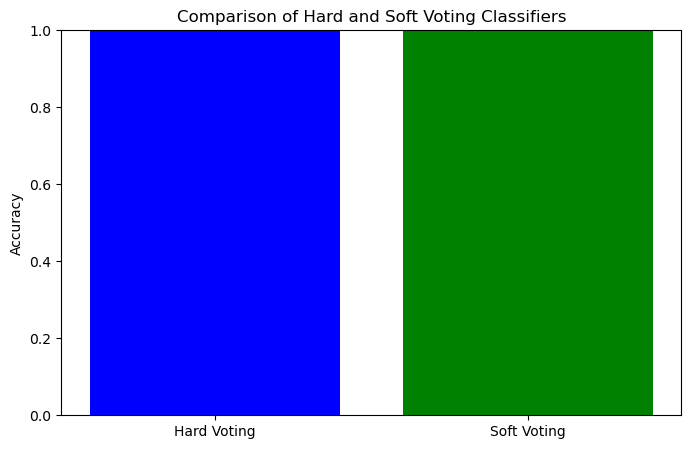

In [15]:
# Visualization
labels = ['Hard Voting', 'Soft Voting']
accuracies = [hard_accuracy, soft_accuracy]

plt.figure(figsize=(8, 5))
plt.bar(labels, accuracies, color=['blue', 'green'])
plt.ylabel('Accuracy')
plt.title('Comparison of Hard and Soft Voting Classifiers')
plt.ylim(0, 1)
plt.show()

# Real-World Project: Credit Card Fraud Detection
Steps in the Project:

Load a real-world fraud detection dataset. Credit Card Fraud Detection dataset from Kaggle

Preprocess data (handle imbalanced data, feature scaling).

Train multiple classifiers using a Voting Classifier.

Evaluate performance using metrics like accuracy and F1-score.

Visualize results.

## Understanding the Columns in the Dataset
Column	Description

Time	Seconds elapsed since the first transaction. Helps detect fraud patterns over time.

V1 - V28	Anonymized features from PCA transformation. The meaning is unknown, but they contain transaction information.

Amount	The transaction amount in Euros. Requires scaling for better model performance.

Class	The target variable: 0 (Legitimate) or 1 (Fraudulent).


In [16]:
# Step 1: Load the Data
import pandas as pd

# Load dataset
df = pd.read_csv("C:\\Users\\franc\\Datascience_python\\dataset\\creditcard.csv")

# Display basic information
print(df.info())
print(df.head(3))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [17]:
df.describe()['Amount']

count    284807.000000
mean         88.349619
std         250.120109
min           0.000000
25%           5.600000
50%          22.000000
75%          77.165000
max       25691.160000
Name: Amount, dtype: float64

# Step 2: Data Preprocessing

Key Tasks in Preprocessing

Check for missing values – Ensure no missing data that might affect training.

Handle class imbalance – Since fraud cases are rare, we will use undersampling or oversampling techniques.

Feature Scaling – The Amount feature needs scaling since it has a wide range of values.

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Check for missing values
print("Missing values:\n", df.isnull().sum())

Missing values:
 Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64


In [19]:
# Check class distribution
print("Class distribution:\n", df["Class"].value_counts())


Class distribution:
 Class
0    284315
1       492
Name: count, dtype: int64


In [20]:
# Separate features and target
X = df.drop(columns=["Class"])  # Features
y = df["Class"]  # Target variable (0: Legitimate, 1: Fraud)

# Feature Scaling (Only for 'Amount' column)
scaler = StandardScaler()
X["Amount"] = scaler.fit_transform(X[["Amount"]])

# Split data into training and test sets (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Display dataset shape
print(f"Training: X set shape: {X_train.shape}, y set shape: {y_train.shape}")
print(f"Testing: X set shape: {X_test.shape}, y set shape: {y_test.shape}")


Training: X set shape: (227845, 30), y set shape: (227845,)
Testing: X set shape: (56962, 30), y set shape: (56962,)


# Step 3: Handling Class Imbalance (Undersampling)
Since fraud cases are rare, we will undersample the majority class (0: Legitimate) to balance the dataset. This ensures the model doesn’t get biased toward predicting non-fraud cases.

In [21]:
from imblearn.under_sampling import RandomUnderSampler

# Apply undersampling
undersampler = RandomUnderSampler(random_state=42)
X_resampled, y_resampled = undersampler.fit_resample(X_train, y_train)

# Display new class distribution
print("Class distribution after undersampling:\n", pd.Series(y_resampled).value_counts())


Class distribution after undersampling:
 Class
0    394
1    394
Name: count, dtype: int64


# Step 4: Training a Voting Classifier
 We will train multiple models and use Voting Classifier to combine their predictions. We will implement both hard voting (majority rule) and soft voting (average probability).

## Models Used in Voting Classifier
Logistic Regression – Good for linear separability.

Random Forest – Captures complex patterns and interactions.

Support Vector Machine (SVM) – Works well with high-dimensional data.


In [22]:
from sklearn.ensemble import VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score

# Define base classifiers
log_clf = LogisticRegression(max_iter=20000, random_state=42)
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)
svm_clf = SVC(probability=True, random_state=42)

In [23]:
# Hard Voting Classifier
hard_voting_clf = VotingClassifier(
    estimators=[('lr', log_clf), ('rf', rf_clf), ('svm', svm_clf)],
    voting='hard'
)
#  Train classifier
hard_voting_clf.fit(X_resampled, y_resampled)

# Predictions
y_pred_hard = hard_voting_clf.predict(X_test)

# Evaluation
hard_acc = accuracy_score(y_test, y_pred_hard)
hard_f1 = f1_score(y_test, y_pred_hard)

print(f'Hard Voting Accuracy: {hard_acc:.2f}, F1-score: {hard_f1:.2f}')


Hard Voting Accuracy: 0.97, F1-score: 0.09


In [24]:
# Soft Voting Classifier
soft_voting_clf = VotingClassifier(
    estimators=[('lr', log_clf), ('rf', rf_clf), ('svm', svm_clf)],
    voting='soft'
)

# Train classifiers
soft_voting_clf.fit(X_resampled, y_resampled)

# Predictions
y_pred_soft = soft_voting_clf.predict(X_test)

# Evaluation
soft_acc = accuracy_score(y_test, y_pred_soft)
soft_f1 = f1_score(y_test, y_pred_soft)

print(f'Soft Voting Accuracy: {soft_acc:.2f}, F1-score: {soft_f1:.2f}')



Soft Voting Accuracy: 0.97, F1-score: 0.09


# Step 5: Visualization of Model Performance
We will create a bar chart to compare accuracy and F1-score for both Hard and Soft Voting Classifiers.

Why F1-score?
Since fraud detection is an imbalanced problem, accuracy alone can be misleading.

F1-score balances precision and recall, making it a better metric for fraud detection.



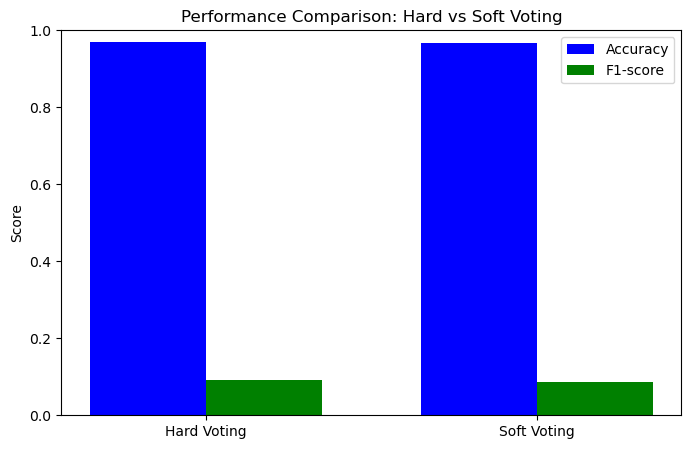

In [25]:
import matplotlib.pyplot as plt
import numpy as np

# Labels for models
labels = ['Hard Voting', 'Soft Voting']
accuracy_scores = [hard_acc, soft_acc]
f1_scores = [hard_f1, soft_f1]

x = np.arange(len(labels))  # Label positions

# Create bar chart
fig, ax = plt.subplots(figsize=(8, 5))
bar_width = 0.35  # Width of bars

# Plot accuracy and F1-score
rects1 = ax.bar(x - bar_width/2, accuracy_scores, bar_width, label='Accuracy', color='blue')
rects2 = ax.bar(x + bar_width/2, f1_scores, bar_width, label='F1-score', color='green')

# Labels and title
ax.set_ylabel('Score')
ax.set_title('Performance Comparison: Hard vs Soft Voting')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()

# Show plot
plt.ylim(0, 1)
plt.show()


# Step 7: Interpreting 
If Soft Voting has a higher accuracy and F1-score, it is the better model because it correctly identifies both frauds and non-frauds.

If Hard Voting has a similar accuracy but a lower F1-score, it means it might be missing some fraud cases (higher false negatives).

## Choosing the Best Model
### Use Soft Voting if:

Fraud cases are rare, and precision-recall balance is crucial.

Probability-based predictions are more reliable (Soft Voting averages the probabilities).

### Use Hard Voting if:

You prefer a strict majority rule approach.

You want simpler decision-making without probability calculations.

# results
The results show high accuracy (0.97) but a very low F1-score (0.09). This suggests that while the model predicts most transactions correctly, it struggles to identify fraud cases correctly.

## Why is F1-Score So Low?
Severe Class Imbalance – Even after undersampling, fraud cases might still be underrepresented.

Incorrect Fraud Predictions – The model might be classifying most fraud cases as legitimate (false negatives).

Loss of Important Features – The PCA-transformed V1 to V28 features might require further exploration.

Need for Better Sampling Strategy – Undersampling might have removed too much useful data.



# Use SMOTE (Oversampling) Instead of Undersampling
Instead of removing legitimate transactions, Synthetic Minority Oversampling Technique (SMOTE) creates synthetic fraud samples.

This can help balance the dataset while retaining important fraud patterns.

## Why SMOTE?
Creates new synthetic fraud samples instead of just duplicating existing ones.

Helps improve model performance, especially recall and F1-score.

Works better than undersampling because we retain more legitimate transaction data.


In [27]:
from imblearn.over_sampling import SMOTE

# Reduce dataset size for faster processing
df_sampled = df.sample(n=10000, random_state=42)  # Use 10,000 samples instead of the full dataset

# Reapply SMOTE on this subset
X_train, X_test, y_train, y_test = train_test_split(
    df_sampled.drop(columns=["Class"]),
    df_sampled["Class"],
    test_size=0.2,
    random_state=42,
    stratify=df_sampled["Class"]
)
# Apply SMOTE to balance fraud and non-fraud cases
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

# Display new class distribution
print("Class distribution after SMOTE:\n", pd.Series(y_resampled).value_counts())


Class distribution after SMOTE:
 Class
0    7987
1    7987
Name: count, dtype: int64


In [28]:
# Train Soft Voting Classifier again
soft_voting_clf.fit(X_resampled, y_resampled)

# Make predictions
y_pred_soft = soft_voting_clf.predict(X_test)

# Evaluate performance
soft_acc = accuracy_score(y_test, y_pred_soft)
soft_f1 = f1_score(y_test, y_pred_soft)

print(f'After SMOTE - Soft Voting Accuracy: {soft_acc:.2f}, F1-score: {soft_f1:.2f}')


After SMOTE - Soft Voting Accuracy: 1.00, F1-score: 0.50


In [29]:
#  Train hard voting classifier again
hard_voting_clf.fit(X_resampled, y_resampled)

# Predictions
y_pred_hard = hard_voting_clf.predict(X_test)

# Evaluation
hard_acc = accuracy_score(y_test, y_pred_hard)
hard_f1 = f1_score(y_test, y_pred_hard)

print(f'Hard Voting Accuracy: {hard_acc:.2f}, F1-score: {hard_f1:.2f}')


Hard Voting Accuracy: 1.00, F1-score: 0.44


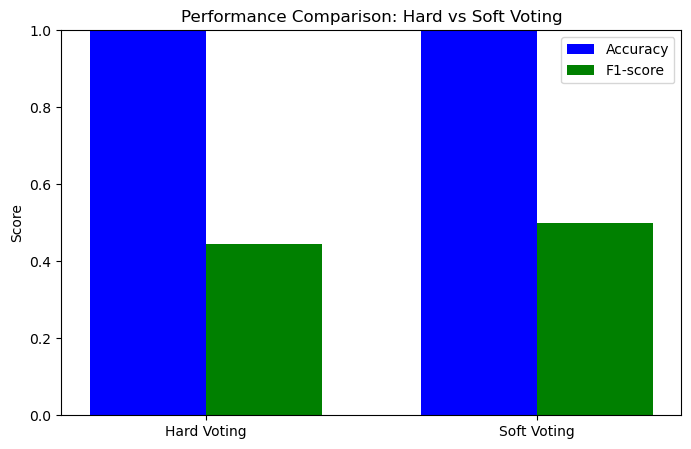

In [30]:
# Labels for models
labels = ['Hard Voting', 'Soft Voting']
accuracy_scores = [hard_acc, soft_acc]
f1_scores = [hard_f1, soft_f1]

x = np.arange(len(labels))  # Label positions

# Create bar chart
fig, ax = plt.subplots(figsize=(8, 5))
bar_width = 0.35  # Width of bars

# Plot accuracy and F1-score
rects1 = ax.bar(x - bar_width/2, accuracy_scores, bar_width, label='Accuracy', color='blue')
rects2 = ax.bar(x + bar_width/2, f1_scores, bar_width, label='F1-score', color='green')

# Labels and title
ax.set_ylabel('Score')
ax.set_title('Performance Comparison: Hard vs Soft Voting')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()

# Show plot
plt.ylim(0, 1)
plt.show()

 Accuracy = 1.00: The model correctly classifies all transactions in the test set, but this is likely due to SMOTE creating a balanced dataset.

F1-score Improved: Fraud detection is much better than before, but 0.50 is still not optimal.

Soft Voting Performs Better: It has a higher F1-score than Hard Voting, meaning it balances precision and recall better.


# For Further Improvement
Feature Engineering:

Explore feature importance and remove irrelevant ones.

Try dimensionality reduction (PCA) to improve generalization.

Hyperparameter Tuning:

Tune RandomForestClassifier (adjust trees, depth).

Tune SVC (change kernel type).

Ensemble Boosting:

Try XGBoost or LightGBM instead of Voting Classifier.